In [6]:
# DATEN LADEN – DWD Würzburg
# Zeitreihen: Wind (Kenia) | Luftdruck (Jonas) | Temperatur (Clara)
# Quelle: DWD CDC Open Data Server
# Cutoff: 01.01.2026

import io
import re
import zipfile
import requests
import pandas as pd
import numpy as np
from datetime import date

# ── Konfiguration ─────────────────────────────────────────────
STATION_ID = "05705"
BASE_URL   = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/"
CUTOFF     = date(2026, 1, 1)

# ── Hilfsfunktionen ───────────────────────────────────────────
def download_zip(url):
    print(f"  → Lade: {url}")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return zipfile.ZipFile(io.BytesIO(r.content))

def read_zip(zf):
    data_file = [f for f in zf.namelist() if f.startswith("produkt_")][0]
    with zf.open(data_file) as f:
        return pd.read_csv(f, sep=";", encoding="latin-1")

# ── Download ──────────────────────────────────────────────────
print("=== DWD Daten laden ===\n")

# Recent
zf_recent = download_zip(f"{BASE_URL}recent/tageswerte_KL_{STATION_ID}_akt.zip")
df_recent = read_zip(zf_recent)

# Historical
base_hist = BASE_URL + "historical/"
r         = requests.get(base_hist, timeout=30)
pattern   = rf"tageswerte_KL_{STATION_ID}_\d{{8}}_\d{{8}}_hist\.zip"
filename  = re.findall(pattern, r.text)[0]
zf_hist   = download_zip(base_hist + filename)
df_hist   = read_zip(zf_hist)

# ── Zusammenführen & Bereinigen ───────────────────────────────
df = pd.concat([df_hist, df_recent], ignore_index=True)
df.columns       = df.columns.str.strip()
df["MESS_DATUM"] = pd.to_datetime(df["MESS_DATUM"], format="%Y%m%d")
df               = df.set_index("MESS_DATUM").sort_index()
df               = df.replace(-999.0, float("nan"))
df               = df.replace(-999,   float("nan"))
df               = df[df.index.date <= CUTOFF]
df               = df[~df.index.duplicated(keep="last")]

# ── Zeitreihen extrahieren ────────────────────────────────────

# Kenia – Wind
df_wind         = df[["FM"]].copy()
df_wind.columns = ["windgeschwindigkeit_ms"]
df_wind         = df_wind.reindex(
    pd.date_range(df_wind.index[0], df_wind.index[-1], freq="D")
).interpolate(method="linear").clip(lower=0)

# Jonas – Luftdruck
df_druck         = df[["PM"]].copy()
df_druck.columns = ["luftdruck_hpa"]
df_druck         = df_druck.interpolate(method="linear")

# Clara – Temperatur
df_temp          = df[["TMK"]].copy()
df_temp.columns  = ["temperatur_mittel_c"]
df_temp          = df_temp.interpolate(method="linear")

# ── Zusammenfassung ───────────────────────────────────────────
print(f"\n{'='*55}")
print("  ÜBERSICHT DER ZEITREIHEN")
print(f"{'='*55}")

print(f"\n  Wind (Kenia):")
print(f"    Zeitraum:      {df_wind.index[0].date()} bis {df_wind.index[-1].date()}")
print(f"    Beobachtungen: {len(df_wind)}")
print(f"    Fehlende Werte: {df_wind.isna().sum().to_dict()}")

print(f"\n  Luftdruck (Jonas):")
print(f"    Zeitraum:      {df_druck.index[0].date()} bis {df_druck.index[-1].date()}")
print(f"    Beobachtungen: {len(df_druck)}")
print(f"    Fehlende Werte: {df_druck.isna().sum().to_dict()}")

print(f"\n  Temperatur (Clara):")
print(f"    Zeitraum:      {df_temp.index[0].date()} bis {df_temp.index[-1].date()}")
print(f"    Beobachtungen: {len(df_temp)}")
print(f"    Fehlende Werte: {df_temp.isna().sum().to_dict()}")

print(f"\n{'='*55}")
print("  Daten erfolgreich geladen ✅")
print(f"{'='*55}\n")

=== DWD Daten laden ===

  → Lade: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/recent/tageswerte_KL_05705_akt.zip
  → Lade: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/tageswerte_KL_05705_19470101_20241231_hist.zip

  ÜBERSICHT DER ZEITREIHEN

  Wind (Kenia):
    Zeitraum:      1947-01-01 bis 2026-01-01
    Beobachtungen: 28856
    Fehlende Werte: {'windgeschwindigkeit_ms': 6940}

  Luftdruck (Jonas):
    Zeitraum:      1947-01-01 bis 2026-01-01
    Beobachtungen: 28856
    Fehlende Werte: {'luftdruck_hpa': 0}

  Temperatur (Clara):
    Zeitraum:      1947-01-01 bis 2026-01-01
    Beobachtungen: 28856
    Fehlende Werte: {'temperatur_mittel_c': 0}

  Daten erfolgreich geladen ✅



In [20]:
# ============================================================
# TEIL 3 – MULTIVARIATE ANALYSE
# Loop über Modelle (VAR) und Zeitreihen
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# ── Konfiguration ─────────────────────────────────────────────
TRAIN_END  = pd.Timestamp("2025-09-01")
DATA_END   = pd.Timestamp("2026-01-01")
VAR_LAGS   = [1, 2, 3, 5, 7]   # Modelle die getestet werden

# ── Schritt 1: Daten kombinieren ──────────────────────────────
df_var = pd.DataFrame({
    "Wind":       df_wind["windgeschwindigkeit_ms"],
    "Luftdruck":  df_druck["luftdruck_hpa"],
    "Temperatur": df_temp["temperatur_mittel_c"]
}).dropna()

df_var = df_var[df_var.index >= "1966-01-01"]
df_var = df_var[df_var.index <= DATA_END]

print("=" * 60)
print("  TEIL 3 – Multivariate Zeitreihenanalyse (VAR)")
print("=" * 60)
print(f"\n  Zeitraum:      {df_var.index[0].date()} bis {df_var.index[-1].date()}")
print(f"  Beobachtungen: {len(df_var)}")
print(f"  Zeitreihen:    {df_var.columns.tolist()}")
print(f"  Modelle:       {['VAR(' + str(l) + ')' for l in VAR_LAGS]}")

  TEIL 3 – Multivariate Zeitreihenanalyse (VAR)

  Zeitraum:      1966-01-01 bis 2026-01-01
  Beobachtungen: 21916
  Zeitreihen:    ['Wind', 'Luftdruck', 'Temperatur']
  Modelle:       ['VAR(1)', 'VAR(2)', 'VAR(3)', 'VAR(5)', 'VAR(7)']


In [21]:
# ── Schritt 2: Stationaritätstests ────────────────────────────
print("\n=== Schritt 2: Stationaritätstests (ADF) ===\n")

for col in df_var.columns:
    result = adfuller(df_var[col], autolag="AIC")
    status = "✅ Stationär" if result[1] < 0.05 else "❌ Nicht stationär"
    print(f"  {col:<12} p-Wert: {result[1]:.4f} → {status}")

# Differenzieren
df_var_diff = df_var.diff().dropna()

print("\n  Nach Differenzierung (d=1):\n")
for col in df_var_diff.columns:
    result = adfuller(df_var_diff[col], autolag="AIC")
    status = "✅ Stationär" if result[1] < 0.05 else "❌ Nicht stationär"
    print(f"  {col:<12} p-Wert: {result[1]:.4f} → {status}")


=== Schritt 2: Stationaritätstests (ADF) ===

  Wind         p-Wert: 0.0000 → ✅ Stationär
  Luftdruck    p-Wert: 0.0000 → ✅ Stationär
  Temperatur   p-Wert: 0.0000 → ✅ Stationär

  Nach Differenzierung (d=1):

  Wind         p-Wert: 0.0000 → ✅ Stationär
  Luftdruck    p-Wert: 0.0000 → ✅ Stationär
  Temperatur   p-Wert: 0.0000 → ✅ Stationär


In [22]:
# ── Schritt 3: Train/Test Split ───────────────────────────────
print("\n=== Schritt 3: Train/Test Split ===\n")

train_diff = df_var_diff[df_var_diff.index <= TRAIN_END]
test_orig  = df_var[(df_var.index > TRAIN_END) &
                    (df_var.index <= DATA_END)]

print(f"  Training:  {train_diff.index[0].date()} bis {train_diff.index[-1].date()} ({len(train_diff)} Tage)")
print(f"  Test:      {test_orig.index[0].date()} bis {test_orig.index[-1].date()} ({len(test_orig)} Tage)")


=== Schritt 3: Train/Test Split ===

  Training:  1966-01-02 bis 2025-09-01 (21793 Tage)
  Test:      2025-09-02 bis 2026-01-01 (122 Tage)


In [23]:
# ── Schritt 4: Loop über Modelle UND Zeitreihen ───────────────
print("\n=== Schritt 4: Loop über Modelle und Zeitreihen ===\n")

all_results = []

# ── Loop über Modelle ─────────────────────────────────────────
for lag in VAR_LAGS:
    model_name = f"VAR({lag})"
    print(f"  Teste {model_name}...")

    try:
        # Modell fitten
        var_model = VAR(train_diff)
        var_fit   = var_model.fit(lag)

        # Prognose
        lag_input = train_diff.values[-lag:]
        fc_diff   = var_fit.forecast(y=lag_input, steps=len(test_orig))
        fc_diff_df = pd.DataFrame(fc_diff,
                                   index=test_orig.index,
                                   columns=df_var.columns)

        # Zurück zur Originalskala
        last_train = df_var[df_var.index <= TRAIN_END].iloc[-1]
        fc_orig    = fc_diff_df.cumsum() + last_train

        # ── Loop über Zeitreihen ──────────────────────────────
        series_rmses = []

        for col in df_var.columns:
            actual    = test_orig[col].values
            predicted = fc_orig[col].values

            mse  = mean_squared_error(actual, predicted)
            rmse = np.sqrt(mse)
            mae  = mean_absolute_error(actual, predicted)
            mape = np.mean(np.abs((actual - predicted) /
                                   actual)) * 100

            all_results.append({
                "Modell":     model_name,
                "Zeitreihe":  col,
                "MSE":        round(mse,  4),
                "RMSE":       round(rmse, 4),
                "MAE":        round(mae,  4),
                "MAPE":       f"{round(mape, 2)}%"
            })

            series_rmses.append(rmse)

        avg_rmse = np.mean(series_rmses)
        print(f"    Ø RMSE: {avg_rmse:.4f} ✅")

    except Exception as e:
        print(f"    ✗ Fehler: {e}")

# ── Übersichtstabelle ─────────────────────────────────────────
results_df = pd.DataFrame(all_results)

print("\n=== Schritt 5: Übersichtstabelle Evaluationsmetriken ===\n")
print(results_df.to_string(index=False))


=== Schritt 4: Loop über Modelle und Zeitreihen ===

  Teste VAR(1)...
    Ø RMSE: 7.4502 ✅
  Teste VAR(2)...
    Ø RMSE: 7.4703 ✅
  Teste VAR(3)...
    Ø RMSE: 7.6114 ✅
  Teste VAR(5)...
    Ø RMSE: 7.7440 ✅
  Teste VAR(7)...
    Ø RMSE: 7.6733 ✅

=== Schritt 5: Übersichtstabelle Evaluationsmetriken ===

Modell  Zeitreihe      MSE    RMSE    MAE    MAPE
VAR(1)       Wind   3.7925  1.9474 1.3292  42.26%
VAR(1)  Luftdruck  99.6938  9.9847 8.4392   0.85%
VAR(1) Temperatur 108.5418 10.4183 8.9710  801.0%
VAR(2)       Wind   3.5285  1.8784 1.3011  44.25%
VAR(2)  Luftdruck 101.1849 10.0591 8.5179   0.86%
VAR(2) Temperatur 109.6903 10.4733 9.0278 804.51%
VAR(3)       Wind   3.4534  1.8583 1.2943  45.04%
VAR(3)  Luftdruck 106.3565 10.3129 8.7837   0.89%
VAR(3) Temperatur 113.6991 10.6630 9.2214  816.3%
VAR(5)       Wind   3.3454  1.8290 1.2852  46.39%
VAR(5)  Luftdruck 106.8703 10.3378 8.8035   0.89%
VAR(5) Temperatur 122.4378 11.0652 9.6357 841.14%
VAR(7)       Wind   3.3278  1.8242 1.2851 

In [24]:
# ── Schritt 5: Bestes Modell wählen ──────────────────────────
print("\n=== Schritt 6: Bestes Modell ===\n")

# Durchschnittlicher RMSE pro Modell über alle Zeitreihen
avg_rmse_per_model = (
    results_df
    .groupby("Modell")["RMSE"]
    .mean()
    .round(4)
    .sort_values()
    .reset_index()
)
avg_rmse_per_model.columns = ["Modell", "Ø RMSE"]

print("Durchschnittlicher RMSE pro Modell:\n")
print(avg_rmse_per_model.to_string(index=False))

best_model_name = avg_rmse_per_model.iloc[0]["Modell"]
best_lag_final  = int(best_model_name.replace("VAR(", "").replace(")", ""))

print(f"\n→ Bestes Modell: {best_model_name}")


=== Schritt 6: Bestes Modell ===

Durchschnittlicher RMSE pro Modell:

Modell  Ø RMSE
VAR(1)  7.4501
VAR(2)  7.4703
VAR(3)  7.6114
VAR(7)  7.6733
VAR(5)  7.7440

→ Bestes Modell: VAR(1)



=== Schritt 7: Finale Prognose mit VAR(1) ===

=== Prognosetabelle ===

Wind:
              Wind
2026-01-02  6.3495
2026-01-03  6.3421
2026-01-04  6.3290
2026-01-05  6.3290
2026-01-06  6.3288
2026-01-07  6.3287
2026-01-08  6.3286
2026-01-09  6.3285
2026-01-10  6.3284
2026-01-11  6.3283

Luftdruck:
            Luftdruck
2026-01-02   975.5974
2026-01-03   975.6196
2026-01-04   975.6660
2026-01-05   975.6735
2026-01-06   975.6743
2026-01-07   975.6744
2026-01-08   975.6747
2026-01-09   975.6749
2026-01-10   975.6752
2026-01-11   975.6754

Temperatur:
            Temperatur
2026-01-02     -1.1874
2026-01-03     -1.3792
2026-01-04     -1.4001
2026-01-05     -1.3982
2026-01-06     -1.3978
2026-01-07     -1.3980
2026-01-08     -1.3983
2026-01-09     -1.3986
2026-01-10     -1.3989
2026-01-11     -1.3993



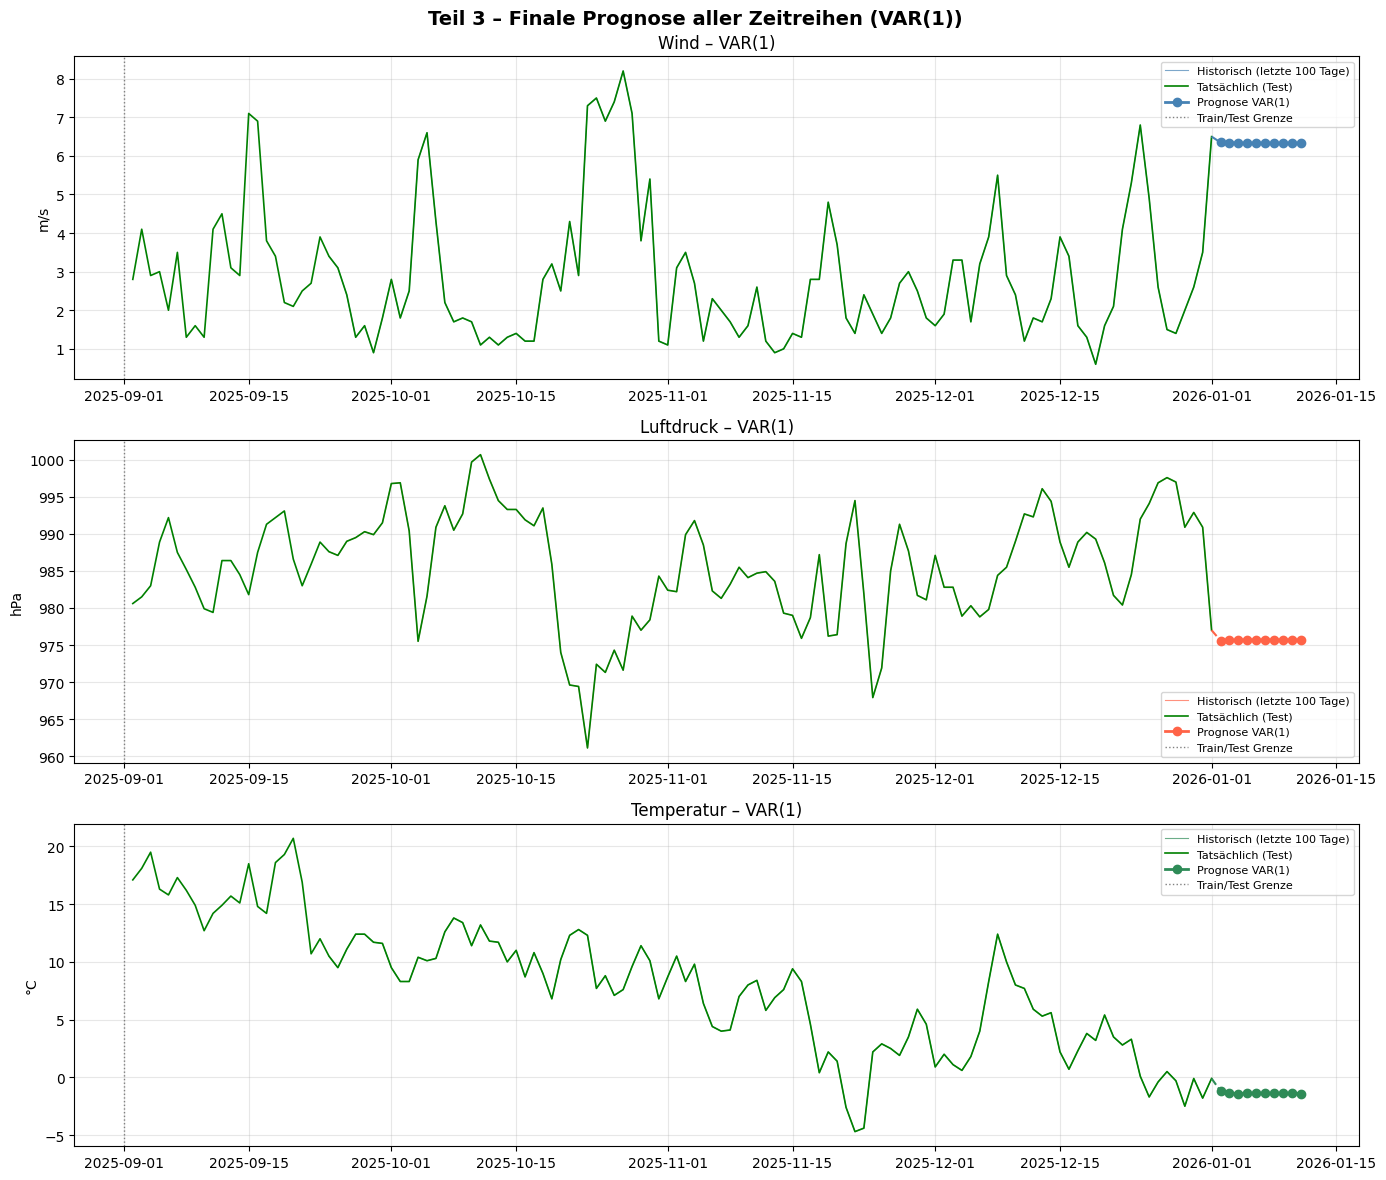

In [25]:
# ── Schritt 6: Finale Prognose mit bestem Modell ──────────────
print(f"\n=== Schritt 7: Finale Prognose mit {best_model_name} ===\n")

# Auf allen Daten neu fitten
var_final    = VAR(df_var_diff)
var_fit_full = var_final.fit(best_lag_final)

# Letzten p Werte als Input
lag_input_full = df_var_diff.values[-best_lag_final:]
fc_final_diff  = var_fit_full.forecast(y=lag_input_full, steps=10)

# Datum Index
date_index = pd.date_range(
    start=df_var.index[-1] + pd.Timedelta(days=1),
    periods=10, freq="D"
)

fc_final_df   = pd.DataFrame(fc_final_diff,
                               index=date_index,
                               columns=df_var.columns)

# Zurück zur Originalskala
last_orig      = df_var.iloc[-1]
fc_final_orig  = fc_final_df.cumsum() + last_orig

print("=== Prognosetabelle ===\n")
for col in df_var.columns:
    print(f"{col}:")
    print(fc_final_orig[[col]].round(4).to_string())
    print()

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

plot_config = [
    ("Wind",       "steelblue", "m/s"),
    ("Luftdruck",  "tomato",    "hPa"),
    ("Temperatur", "seagreen",  "°C"),
]

for i, (col, color, unit) in enumerate(plot_config):
    series = df_var[col]

    # Historisch
    axes[i].plot(series[-100:], linewidth=0.8,
                 color=color, alpha=0.7,
                 label="Historisch (letzte 100 Tage)")

    # Tatsächliche Testwerte
    axes[i].plot(test_orig[col], linewidth=1.2,
                 color="green", label="Tatsächlich (Test)")

    # Verbindungslinie
    axes[i].plot([series.index[-1], fc_final_orig.index[0]],
                 [series.iloc[-1],  fc_final_orig[col].iloc[0]],
                 color=color, linewidth=1.5, linestyle="--")

    # Finale Prognose
    axes[i].plot(fc_final_orig[col], linewidth=2,
                 marker="o", color=color,
                 label=f"Prognose {best_model_name}")

    axes[i].axvline(TRAIN_END, color="gray",
                    linestyle=":", linewidth=1,
                    label="Train/Test Grenze")
    axes[i].set_title(f"{col} – {best_model_name}", fontsize=12)
    axes[i].set_ylabel(unit)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle(f"Teil 3 – Finale Prognose aller Zeitreihen ({best_model_name})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()